In [1]:
%matplotlib inline

import os
from pathlib import Path
import maboss_visualize as mv

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import biobalm
os.chdir('../../../../')
import valley

plt.rcParams["figure.dpi"] = 300   # keeps the saved notebook small; raise it for real figures
DATA = Path("model/autophagy/")
print("maboss_visualize", mv.__version__)
print(sorted(p.name for p in DATA.iterdir()))


ginsim = mv.read_network(DATA / "Autophagy_and _apoptosis.zginml")

maboss_visualize 0.1.0.dev0
['Autophagy_SMW.jl', 'Autophagy_and _apoptosis.zginml', 'Autophagy_and_apoptosis.bnd', 'Autophagy_and_apoptosis.bnd.cfg', 'Autophagy_and_apoptosis.bnet', 'Autophagy_and_apoptosis.png', 'Autophagy_and_apoptosis.sbml', 'Autophagy_and_apoptosis.txt', 'Autophagy_and_apoptosis.xgmml']


## Step 1 — The influence graph

Draw the model structure and check the edge signs first. A high **dual** fraction means the
`.bnet` sign heuristic is failing on this file's syntax, and no structural distance should be
trusted until that is fixed.

The layout computed here is reused by every later network figure, so panels stay comparable.

In [2]:
node_df, edge_df = ginsim.to_frames()
input_list = node_df[node_df['group'] == 'Input'].index.to_list()
output_list = node_df[node_df['group'].isin(['True_output', 'Phenomenons'])].index.to_list()

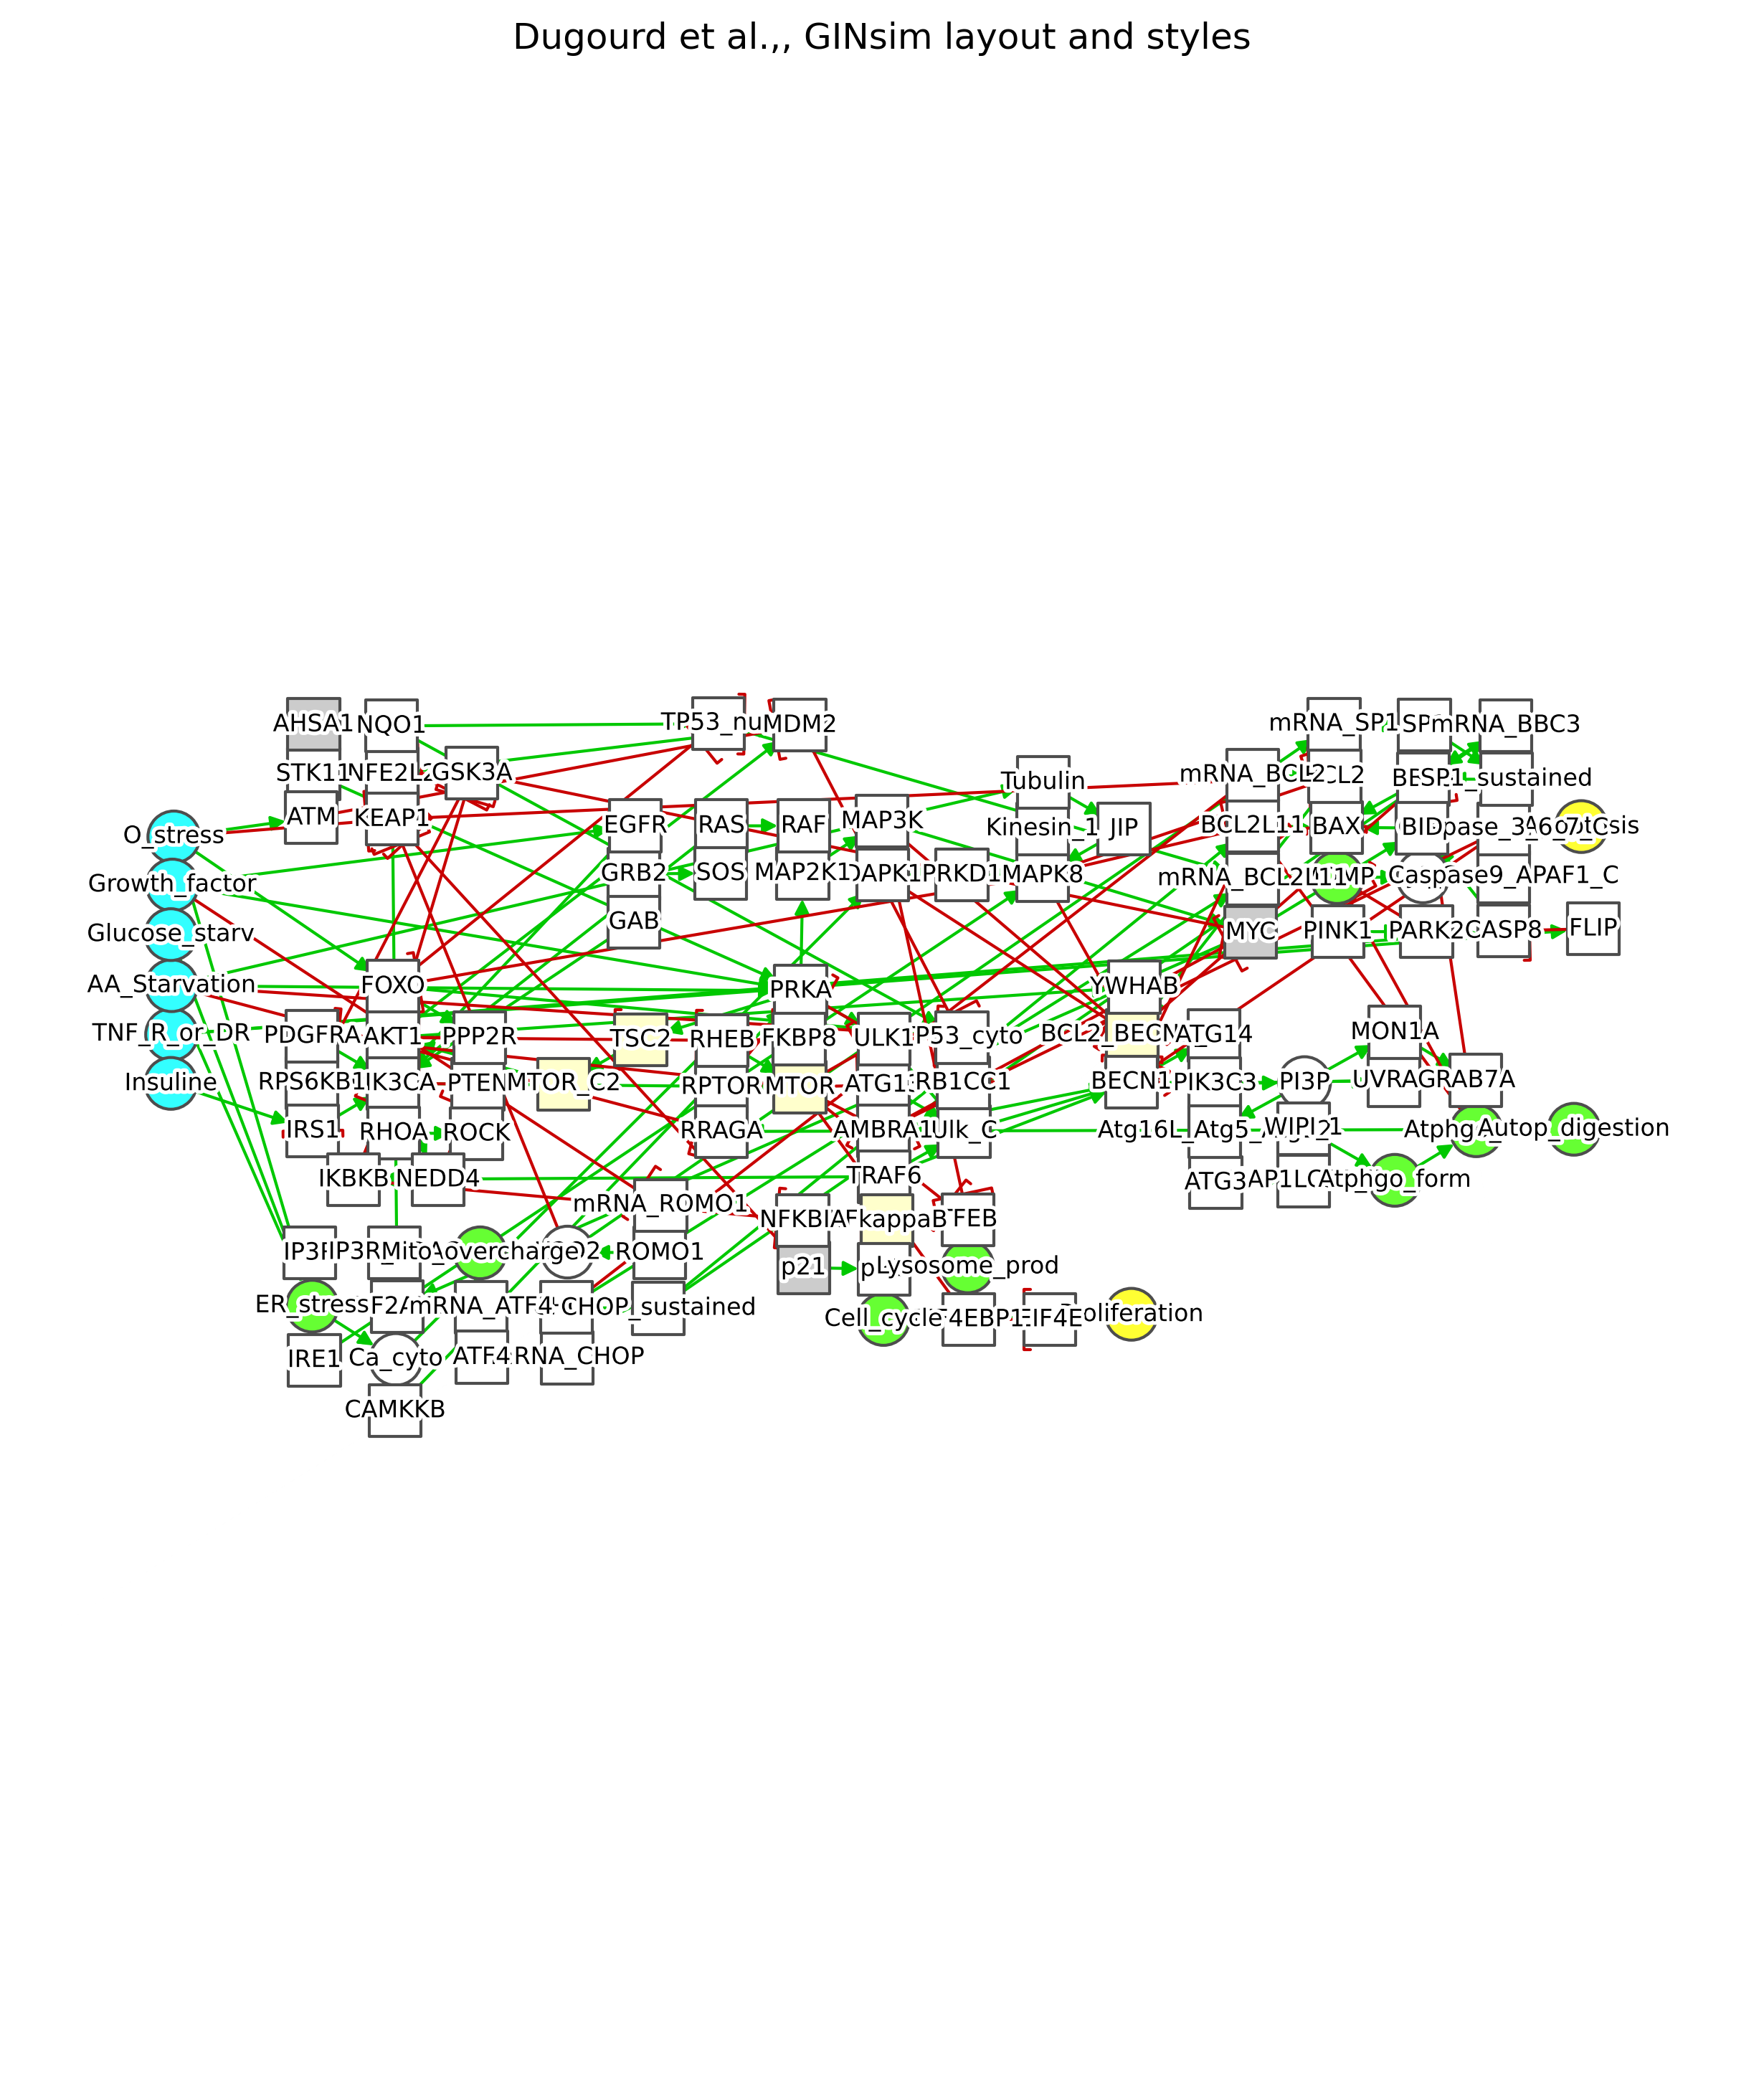

In [3]:
ax = mv.draw_network(ginsim, title="Dugourd et al.,, GINsim layout and styles",
                     figsize = (10,10), node_size=300)

## Step 2 — The attractor set

Computing attractors is out of scope for `valley`; this step only loads them. Produce the table
with `biobalm` on the same `.bnet` file and write it as **one row per attractor, one column per
node**, values in $\{0, 1\}$ — or a mean activity per node for a cyclic attractor. Anything that
yields that table works: `biobalm`, `pystablemotifs`, MaBoSS fixed points.

`state_matrix` aligns the columns to `model.nodes` and fills any missing node with 0, so the
report below flags what was dropped.

In [4]:
BNET_PATH = DATA / "Autophagy_and_apoptosis.bnet"

# Load the model
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
model = sd.network

# Build the succession diagram
sd.build() 
sd.summary()

# Save the succession diagram to a network object
G = sd.dag

# Convert the succession diagram DAG to a DataFrame for analysis
node_list = sd.network.variable_names()
data = sd.dag.nodes(data=True)
indexes_sorted = []
index_list = []
# Extract states from GM nodes and append attractor tag
for _, data in sd.dag.nodes(data=True):
    if 'space' not in data:
        continue

    index = data['space']
    # Reorder `index` to follow the order in `node_list`
    index = {k: index.get(k, '*') for k in node_list}

    # Check whether the node is an attractor candidate and assign tag accordingly
    obj = data.get('attractor_candidates')
    index['tag'] = 't' if obj is None else 'a'

    # Add model tag back to the node data for later use
    index_string = ''.join(str(index.get(k, '*')) for k in node_list + ['tag'])
    sd.dag.nodes[_]['index'] = index_string

    # Compile the index list
    indexes_sorted.append(index)

    # Check index list
    index_list.append(index_string)

# Create a DataFrame from the sorted indexes
sd_states = pd.DataFrame(indexes_sorted)

# Filter the DataFrame to only include attractor states
attractor_states = sd_states.loc[sd_states['tag'] == 'a']
attractor_states = attractor_states.drop(columns=['tag']).replace('*',0.5).astype(float)

In [5]:
from matplotlib.patches import Patch

activity_colors = {0.0: "#3b4cc0", 0.5: "#f7f7f7", 1.0: "#b40426"}

# rows = attractors (match clustermap columns), columns = one colour track per input
input_col_colors = attractor_states.loc[:, input_list].apply(
    lambda activity: activity.map(activity_colors)
)

g = sns.clustermap(
    attractor_states.drop(columns=input_list).T,  # inputs shown only as colour tracks
    method="ward",
    metric="euclidean",
    cmap="vlag",
    linewidths=0.1,
    col_colors=input_col_colors,
    figsize=(30, 24),
    yticklabels=True,
    xticklabels=True,
)

# legend for the input colour tracks
handles = [
    Patch(facecolor=activity_colors[0.0], label="input OFF"),
    Patch(facecolor=activity_colors[1.0], label="input ON"),
]
g.ax_col_dendrogram.legend(
    handles=handles, title="Input activity (colour tracks)",
    loc="center", ncol=2, frameon=False,
)
g.fig.suptitle("Attractors clustered by node activity, annotated by input state", y=1.01)

Text(0.5, 1.01, 'Attractors clustered by node activity, annotated by input state')

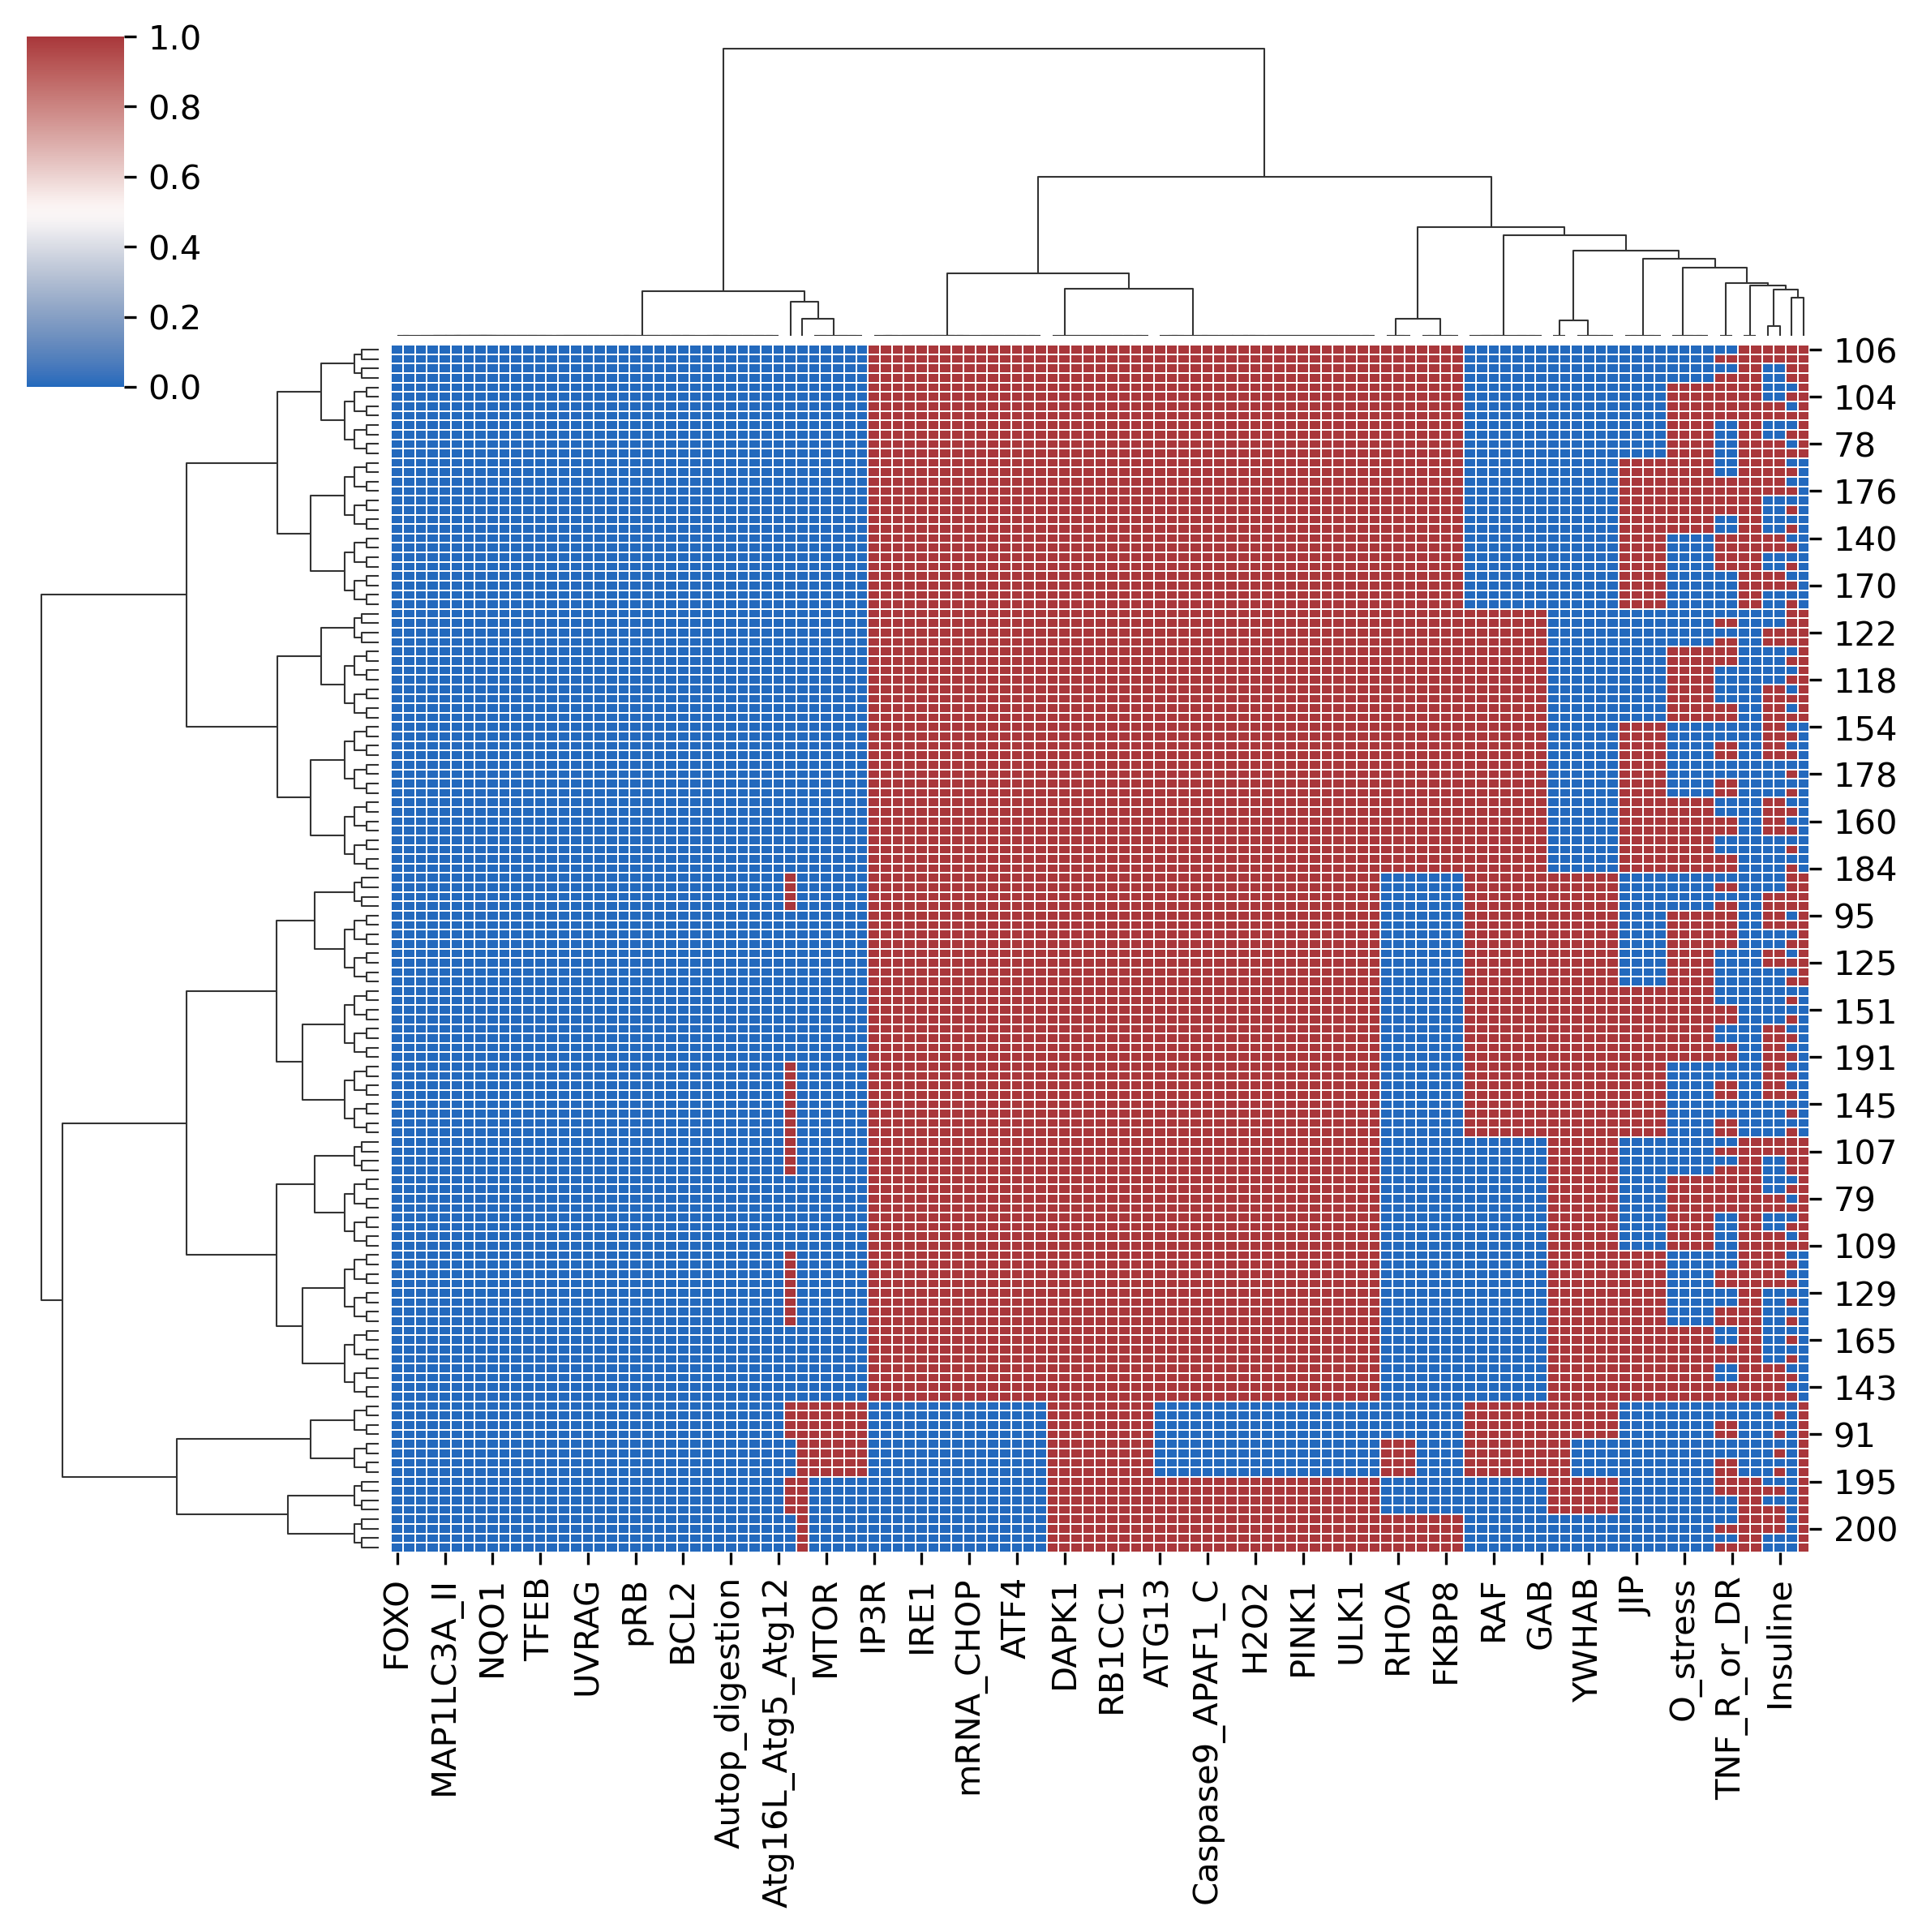

In [6]:
sns.clustermap(attractor_states, method='ward', metric='euclidean', cmap='vlag', linewidths=0.1, figsize=(8, 8))

### Which input combination gives which output phenotype?

A truth table rather than a clustermap: one row per input combination, rows grouped by the
output pattern (phenotype class `P1…`, with the number of combinations in brackets). Within a
class, the inputs that change from row to row do not matter for that phenotype; the inputs that
stay the same define it. `n att.` counts attractors per row. A `*` would mark a combination whose
attractors reach different output patterns (true phenotypic multistability).

,n_combinations,n_attractors,O_stress_ON,Growth_factor_ON,TNF_R_or_DR_ON,AA_Starvation_ON,Insuline_ON,Glucose_starv_ON
phenotype,,,,,,,,
1,56,112,0.57,0.5,0.5,0.57,0.5,0.57
2,4,8,0.00,0.0,0.5,0.00,0.5,0.00
3,4,8,0.00,1.0,0.5,0.00,0.5,0.00


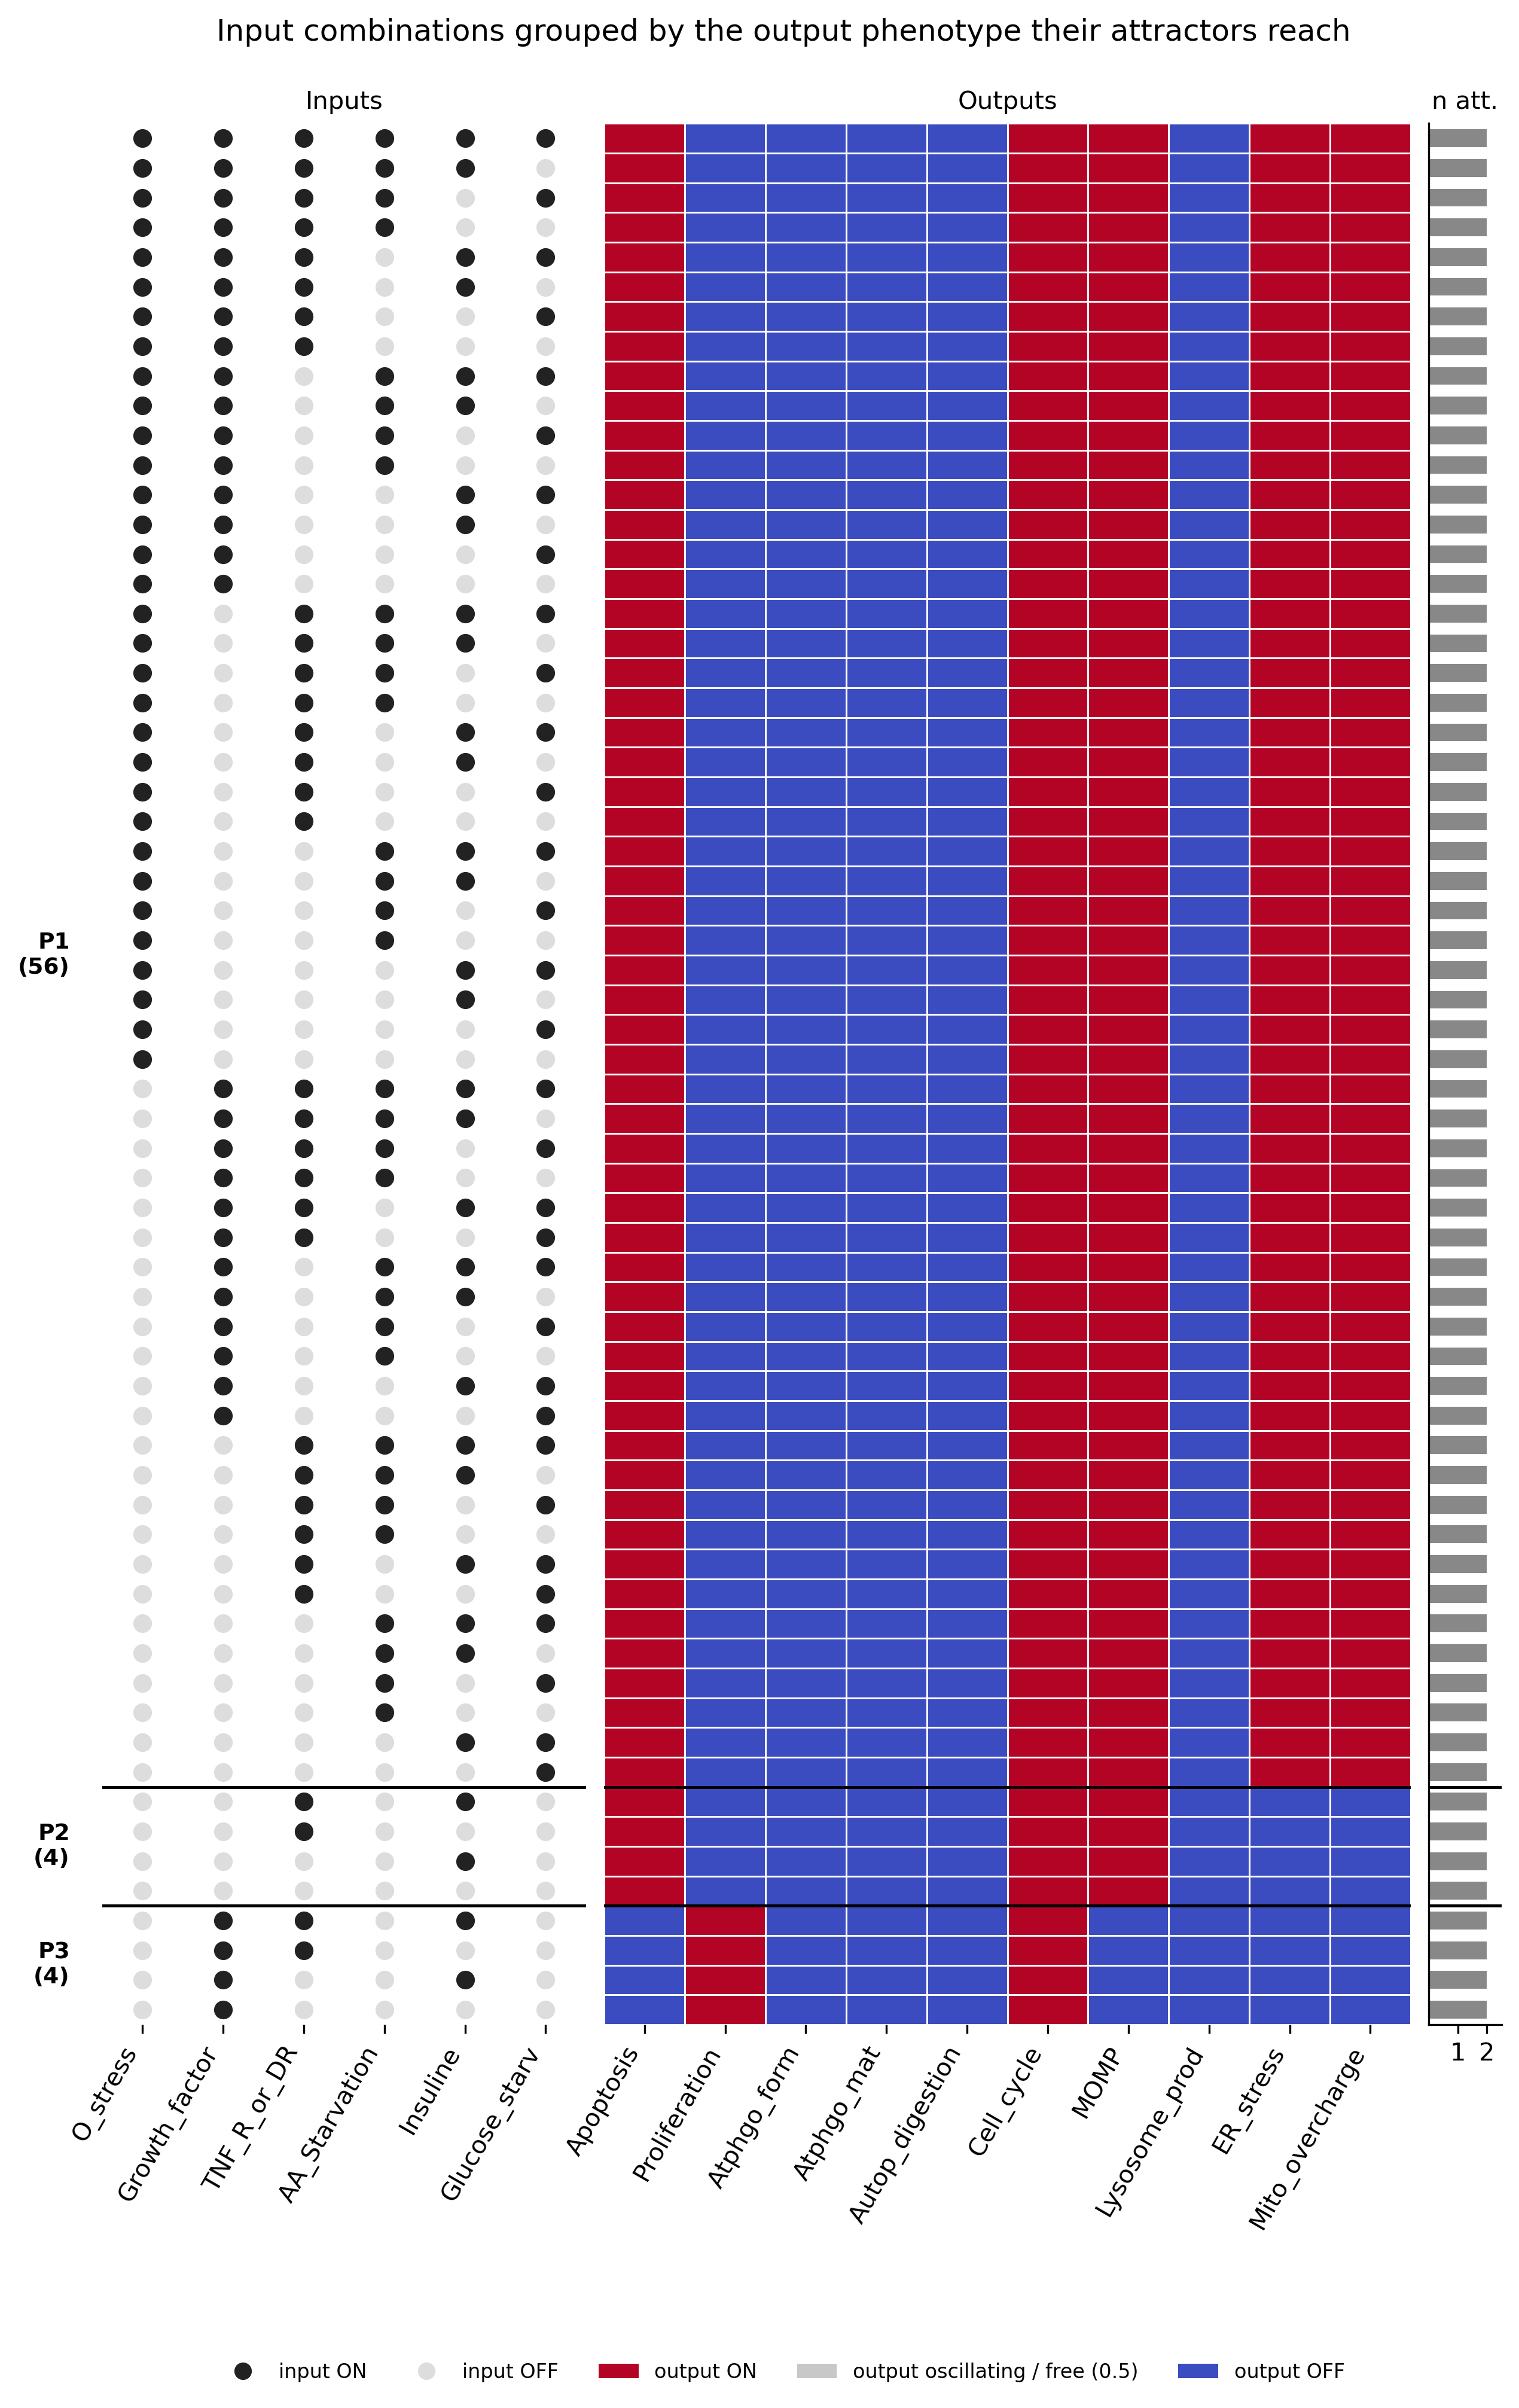

In [7]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- Input combination -> output phenotype truth table -----------------------
# One row per (input combination, output pattern). Bistable combinations whose
# attractors share the same outputs collapse into one row; "n att." counts them.
inputs = attractor_states[input_list].astype(int)
outputs = attractor_states[output_list]

table = (
    pd.concat([inputs, outputs], axis=1)
    .groupby(input_list + output_list, as_index=False)
    .size()
    .rename(columns={"size": "n_attractors"})
)

# Phenotype class = distinct output pattern, numbered by how many combinations reach it
pattern = table[output_list].apply(tuple, axis=1)
class_order = pattern.value_counts().index
table["phenotype"] = pattern.map({p: i + 1 for i, p in enumerate(class_order)})
table = table.sort_values(["phenotype"] + input_list, ascending=[True] + [False] * len(input_list))
table = table.reset_index(drop=True)

# A combination appearing in more than one class is multistable at the phenotype level
combo_key = table[input_list].astype(str).agg("".join, axis=1)
mixed = combo_key.duplicated(keep=False)

n_rows = len(table)
fig, (ax_in, ax_out, ax_n) = plt.subplots(
    1, 3, figsize=(10, 0.17 * n_rows + 2.2), sharey=True,
    gridspec_kw={"width_ratios": [len(input_list), len(output_list), 0.9], "wspace": 0.04},
)
y = np.arange(n_rows)

# Inputs: dot matrix (filled = ON)
for j, name in enumerate(input_list):
    on = table[name].to_numpy() == 1
    ax_in.scatter(np.full(on.sum(), j), y[on], s=42, color="#222222", zorder=3)
    ax_in.scatter(np.full((~on).sum(), j), y[~on], s=42, color="#dddddd", zorder=3)
ax_in.set_xlim(-0.5, len(input_list) - 0.5)
ax_in.set_xticks(range(len(input_list)))
ax_in.set_xticklabels(input_list, rotation=60, ha="right")
ax_in.set_title("Inputs", fontsize=10)

# Outputs: OFF / oscillating (0.5) / ON
state_cmap = ListedColormap(["#3b4cc0", "#c8c8c8", "#b40426"])
state_norm = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], state_cmap.N)
ax_out.pcolormesh(
    np.arange(len(output_list) + 1) - 0.5, np.arange(n_rows + 1) - 0.5,
    table[output_list].to_numpy(), cmap=state_cmap, norm=state_norm,
    edgecolors="white", linewidth=0.6,
)
ax_out.set_xticks(range(len(output_list)))
ax_out.set_xticklabels(output_list, rotation=60, ha="right")
ax_out.set_title("Outputs", fontsize=10)

# Number of attractors per row (>1 = bistable with identical outputs)
ax_n.barh(y, table["n_attractors"], height=0.6, color="#888888")
ax_n.set_xlim(0, table["n_attractors"].max() + 0.5)
ax_n.set_xticks(range(1, table["n_attractors"].max() + 1))
ax_n.set_title("n att.", fontsize=10)
ax_n.spines[["top", "right"]].set_visible(False)

# Phenotype class separators and labels
bounds = np.flatnonzero(np.diff(table["phenotype"].to_numpy())) + 0.5
for ax in (ax_in, ax_out, ax_n):
    for b in bounds:
        ax.axhline(b, color="black", linewidth=1.2)
    ax.tick_params(axis="y", length=0)
for cls, rows in table.groupby("phenotype").groups.items():
    mid = (rows.min() + rows.max()) / 2
    ax_in.text(-0.9, mid, f"P{cls}\n({len(rows)})", ha="right", va="center", fontsize=9, fontweight="bold")
ax_in.set_yticks(y)
ax_in.set_yticklabels(["*" if m else "" for m in mixed], fontsize=9)  # * = combo reaches >1 class
ax_in.set_ylim(n_rows - 0.5, -0.5)
for ax in (ax_in, ax_out):
    ax.spines[:].set_visible(False)

fig.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", color="#222222", label="input ON"),
        Line2D([], [], marker="o", linestyle="", color="#dddddd", label="input OFF"),
        Patch(facecolor="#b40426", label="output ON"),
        Patch(facecolor="#c8c8c8", label="output oscillating / free (0.5)"),
        Patch(facecolor="#3b4cc0", label="output OFF"),
    ],
    loc="lower center", ncol=5, frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle("Input combinations grouped by the output phenotype their attractors reach", y=0.995)
fig.subplots_adjust(left=0.12, bottom=0.14, top=0.95)

# Text version of the same table: fraction of combinations with each input ON, per class
# (1.0 / 0.0 = input fixed in that class, 0.5 = input irrelevant to it)
summary = table.groupby("phenotype").agg(
    n_combinations=("n_attractors", "size"),
    n_attractors=("n_attractors", "sum"),
    **{f"{n}_ON": (n, "mean") for n in input_list},
)
summary.round(2)

### The same phenotype classes on the succession diagram

The biobalm succession diagram `G`, drawn with graphviz `dot` (hierarchical): root → one node per
input combination (labelled with the inputs that are ON) → attractor leaves. Leaves are filled with
their phenotype class `P1…P6` from the truth table above and labelled with it. Intermediate nodes
are tinted with the class of the attractors below them (grey if those attractors disagree).
Nodes are re-ordered by class before layout so each class forms one contiguous block. Set
`RANKDIR = "TB"` for a top-to-bottom tree.

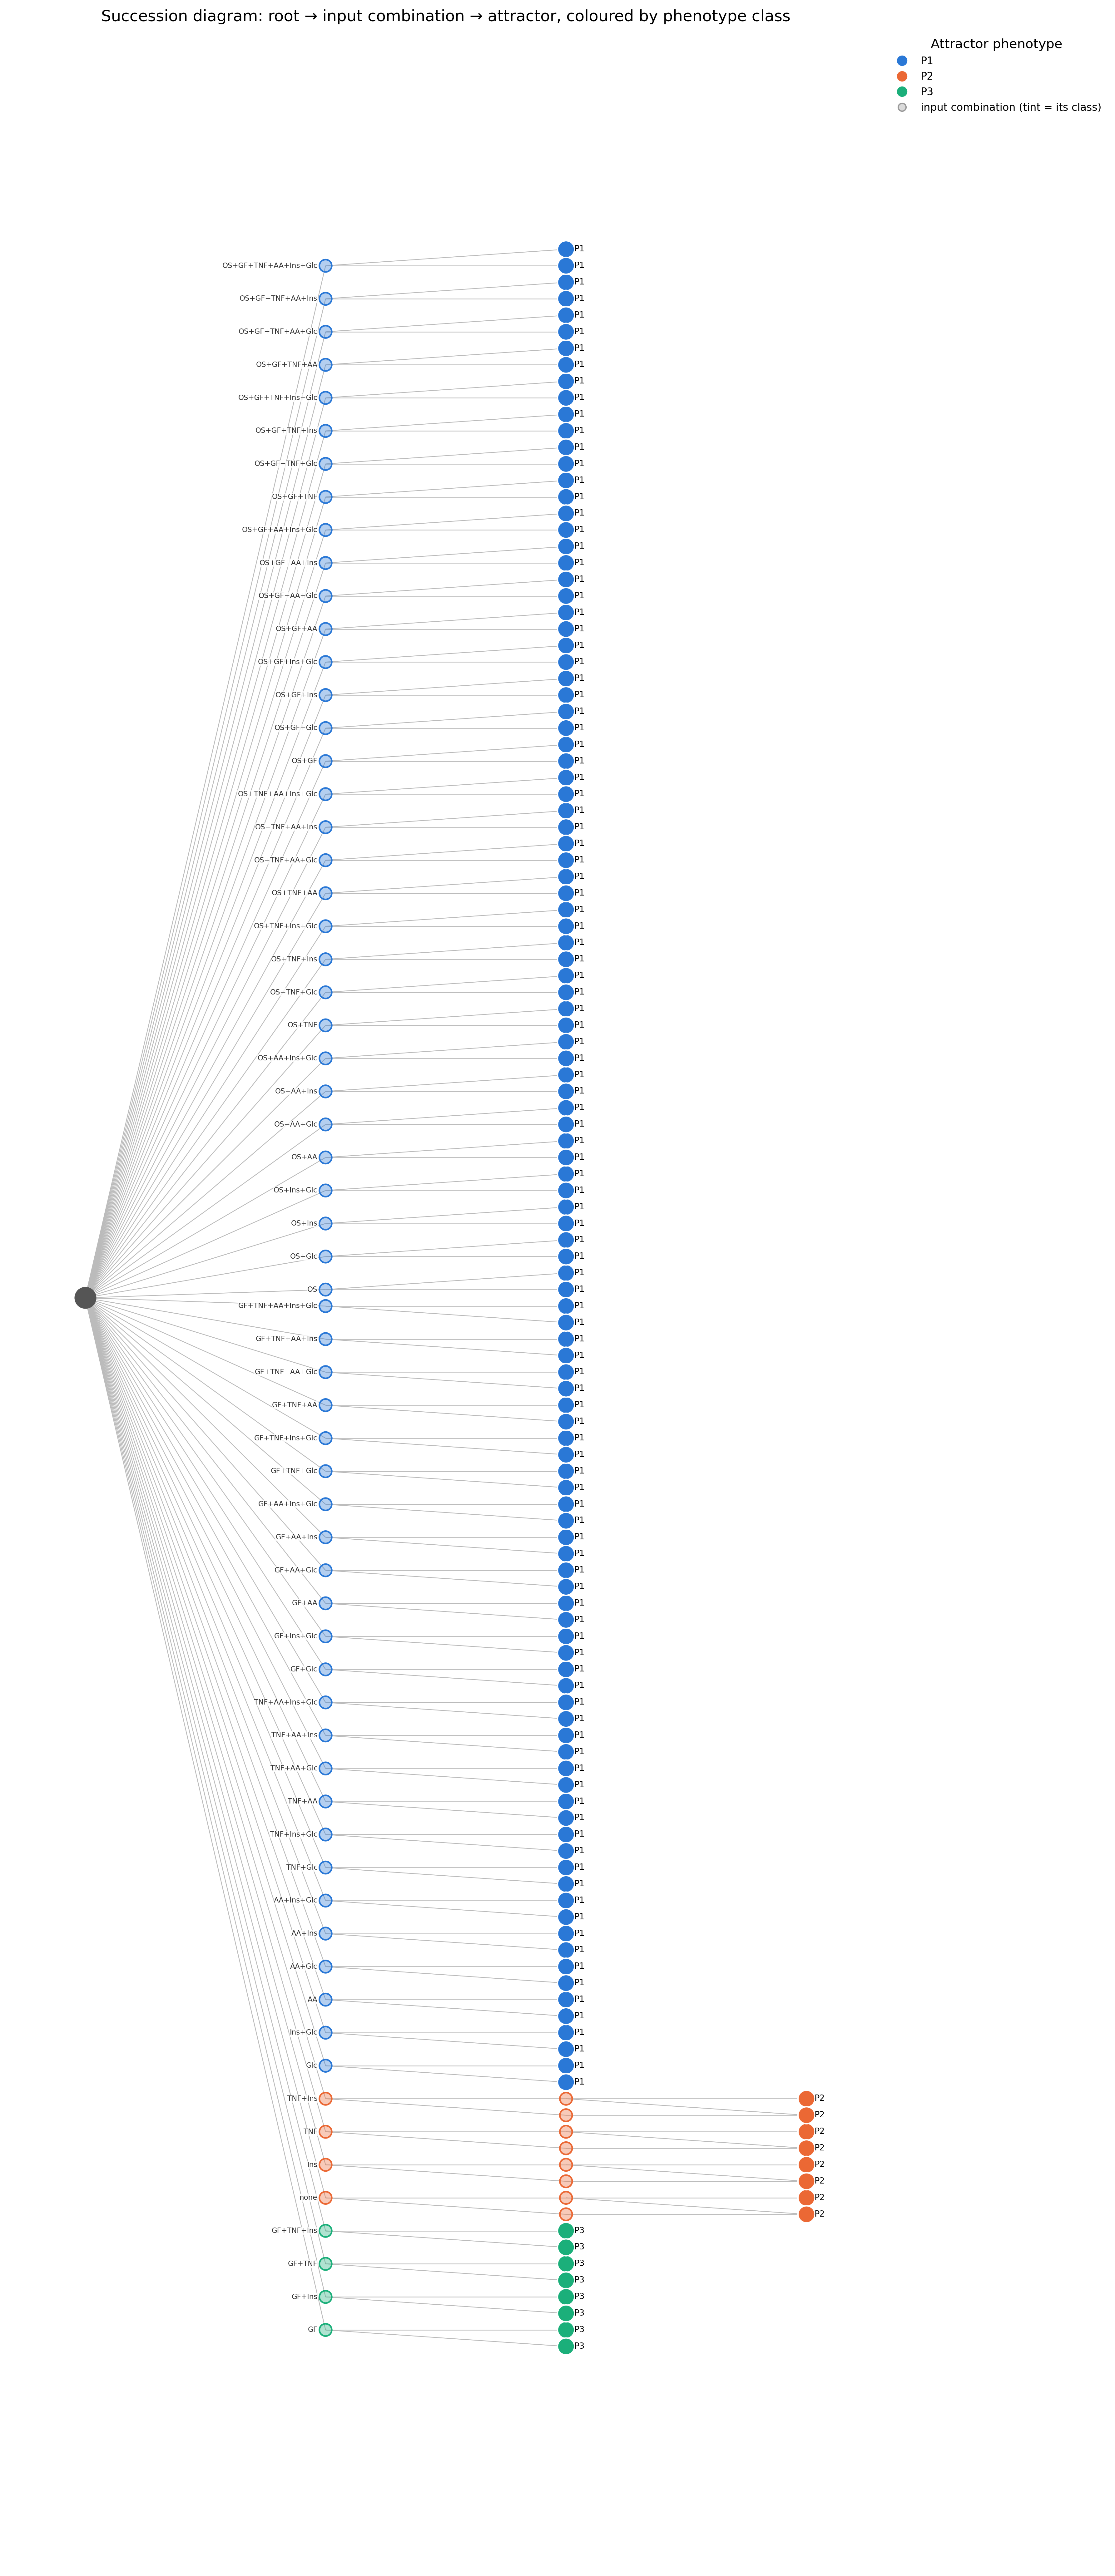

In [8]:
import networkx as nx
from matplotlib.colors import to_rgba

# --- Succession diagram, hierarchical layout, attractors coloured by phenotype class ---
# Classes P1..P6 come from `table` (truth-table cell above): one class per distinct output pattern.
RANKDIR = "LR"   # "TB" for top-to-bottom; LR keeps the 88 leaves readable in a notebook

class_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
                "#4a3aa7", "#e34948"]  # fixed categorical order; slot i -> P(i+1)
pattern_to_class = {
    tuple(row[output_list]): int(row["phenotype"]) for _, row in table.iterrows()
}
input_abbrev = {"O_stress": "OS", "Growth_factor": "GF", "TNF_R_or_DR": "TNF",
                "AA_Starvation": "AA", "Insuline": "Ins", "Glucose_starv": "Glc"}

def node_class(node):
    """Phenotype class of an attractor node (leaf), from its fixed output values."""
    space = G.nodes[node]["space"]
    return pattern_to_class.get(tuple(float(space.get(o, 0.5)) for o in output_list))

leaves = [n for n in G if G.out_degree(n) == 0]
leaf_class = {n: node_class(n) for n in leaves}

# Internal nodes take the class of their leaves when all leaves agree (None = mixed)
subtree_class = {}
for n in G:
    reached = {leaf_class[l] for l in nx.descendants(G, n) | {n} if l in leaf_class}
    subtree_class[n] = reached.pop() if len(reached) == 1 else None

# Re-insert nodes in (class, input combination) order so `dot` draws each class as a block
def sort_key(n):
    space = G.nodes[n]["space"]
    return (subtree_class[n] or 0, tuple(-space.get(i, 0) for i in input_list), n)

H = nx.DiGraph()
H.add_nodes_from(sorted(G, key=sort_key))
for parent in H.nodes:
    H.add_edges_from((parent, child) for child in sorted(G.successors(parent), key=sort_key))
pos = nx.nx_agraph.graphviz_layout(H, prog="dot", args=f"-Grankdir={RANKDIR} -Gordering=out -Gnodesep=0.05 -Granksep=3")

def fill(n, alpha=1.0):
    c = subtree_class[n]
    return to_rgba(class_colors[c - 1], alpha) if c else to_rgba("#9a9a9a", alpha)

combos = [n for n in G.successors(0)]  # depth 1 = one node per input combination
internal = [n for n in G if n not in leaf_class and n != 0]

fig, ax = plt.subplots(figsize=(12, 0.2 * len(leaves) + 2) if RANKDIR == "LR" else (0.2 * len(leaves) + 2, 10))
nx.draw_networkx_edges(H, pos, ax=ax, edge_color="#bbbbbb", width=0.6, arrows=False)
nx.draw_networkx_nodes(H, pos, nodelist=[0], ax=ax, node_color="#555555", node_size=250)
nx.draw_networkx_nodes(H, pos, nodelist=internal, ax=ax, node_size=90,
                       node_color=[fill(n, 0.35) for n in internal],
                       edgecolors=[fill(n) for n in internal], linewidths=1.2)
nx.draw_networkx_nodes(H, pos, nodelist=leaves, ax=ax, node_size=170,
                       node_color=[fill(n) for n in leaves], edgecolors="white", linewidths=1.0)

# Leaf labels: phenotype class (identity is never colour-only)
for n in leaves:
    x, y = pos[n]
    ax.text(x + 9, y, f"P{leaf_class[n]}", ha="left", va="center", fontsize=6.5)
# Input-combination labels: which inputs are ON
for n in combos:
    space = G.nodes[n]["space"]
    on = [input_abbrev.get(i, i) for i in input_list if space.get(i) == 1]
    x, y = pos[n]
    ax.text(x - 9, y, "+".join(on) or "none", ha="right", va="center", fontsize=5.5,
            color="#333333", bbox=dict(boxstyle="square,pad=0.05", fc="white", ec="none", alpha=0.8))

ax.legend(
    handles=[Line2D([], [], marker="o", linestyle="", markersize=7, color=class_colors[c - 1],
                    label=f"P{c}") for c in sorted(table["phenotype"].unique())]
    + [Line2D([], [], marker="o", linestyle="", markersize=6, markerfacecolor=to_rgba("#9a9a9a", 0.35),
              markeredgecolor="#9a9a9a", label="input combination (tint = its class)")],
    title="Attractor phenotype", loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False, fontsize=8,
)
ax.set_title("Succession diagram: root → input combination → attractor, coloured by phenotype class")
ax.set_axis_off()
fig.tight_layout()

### Phenotype classes on the regulatory network

Each attractor in `attractor_states` gets the label of its phenotype class `P1…P6` from the truth table
above. An attractor's class is its output pattern. Averaging every node over the attractors of a class
gives one consensus activity profile per phenotype, which is drawn on the GINsim layout from Step 1.

A node's colour is the fraction of the class's attractors in which it is ON. A value of **0.5 is
ambiguous**: the node may be free or oscillating inside the attractors (`*` → 0.5), or it may be ON in
half of them and OFF in the rest. Inputs that vary within a class (see the summary table above) show
intermediate values for the same reason.

`attractor_states` now has a non-numeric `phenotype` column. Select node columns with `node_cols` before
re-running any of the numeric cells above.

In [9]:
# --- Label every attractor with its phenotype class (same mapping as the truth table) ---
pattern_to_class = {tuple(row[output_list]): int(row["phenotype"]) for _, row in table.iterrows()}
phenotype_order = [f"P{c}" for c in sorted(table["phenotype"].unique())]

attractor_states = attractor_states.assign(phenotype=pd.Categorical(
    [f"P{pattern_to_class[tuple(r)]}" for r in attractor_states[output_list].to_numpy()],
    categories=phenotype_order,
))
attractor_states["phenotype"].value_counts(sort=False)

phenotype
P1    112
P2      8
P3      8
Name: count, dtype: int64

In [10]:
# --- Consensus profile: mean activity of each node over the attractors of a class ---
node_cols = attractor_states.columns.drop("phenotype")
phenotype_activity = attractor_states.groupby("phenotype", observed=True)[node_cols].mean()
phenotype_activity[output_list]

,Apoptosis,Proliferation,Atphgo_form,Atphgo_mat,Autop_digestion,Cell_cycle,MOMP,Lysosome_prod,ER_stress,Mito_overcharge
phenotype,,,,,,,,,,
P1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0
P2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
P3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


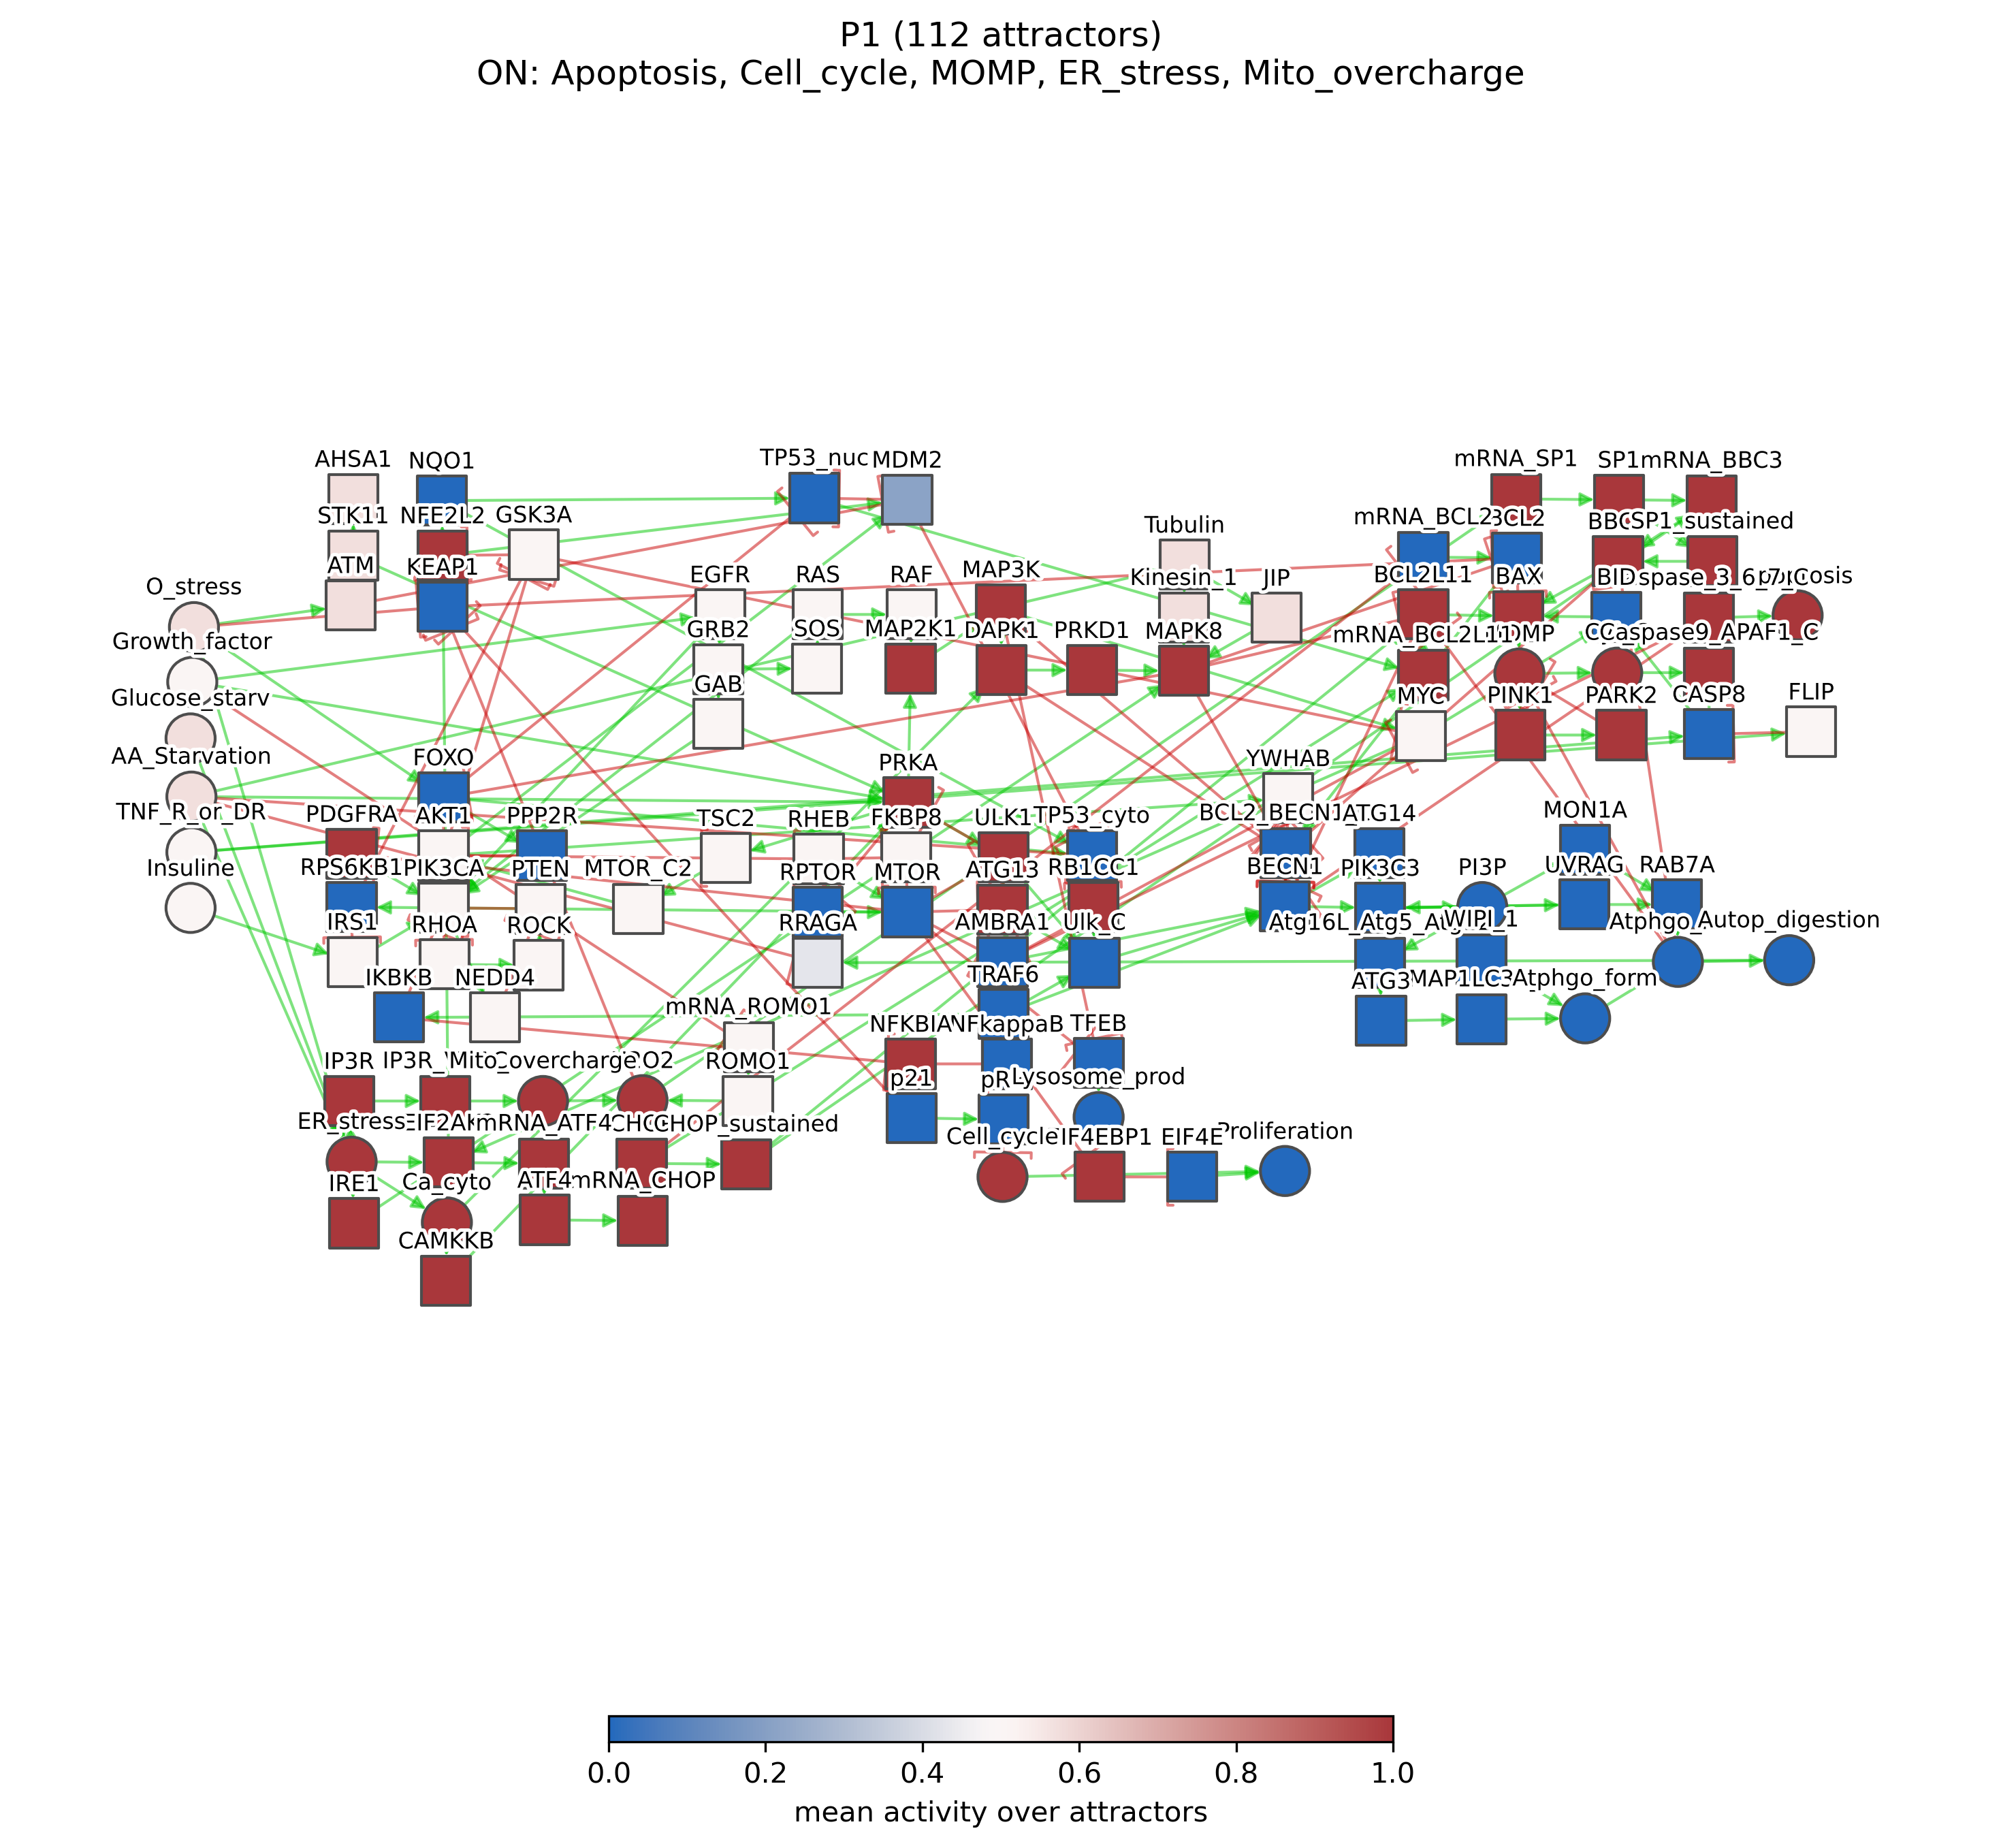

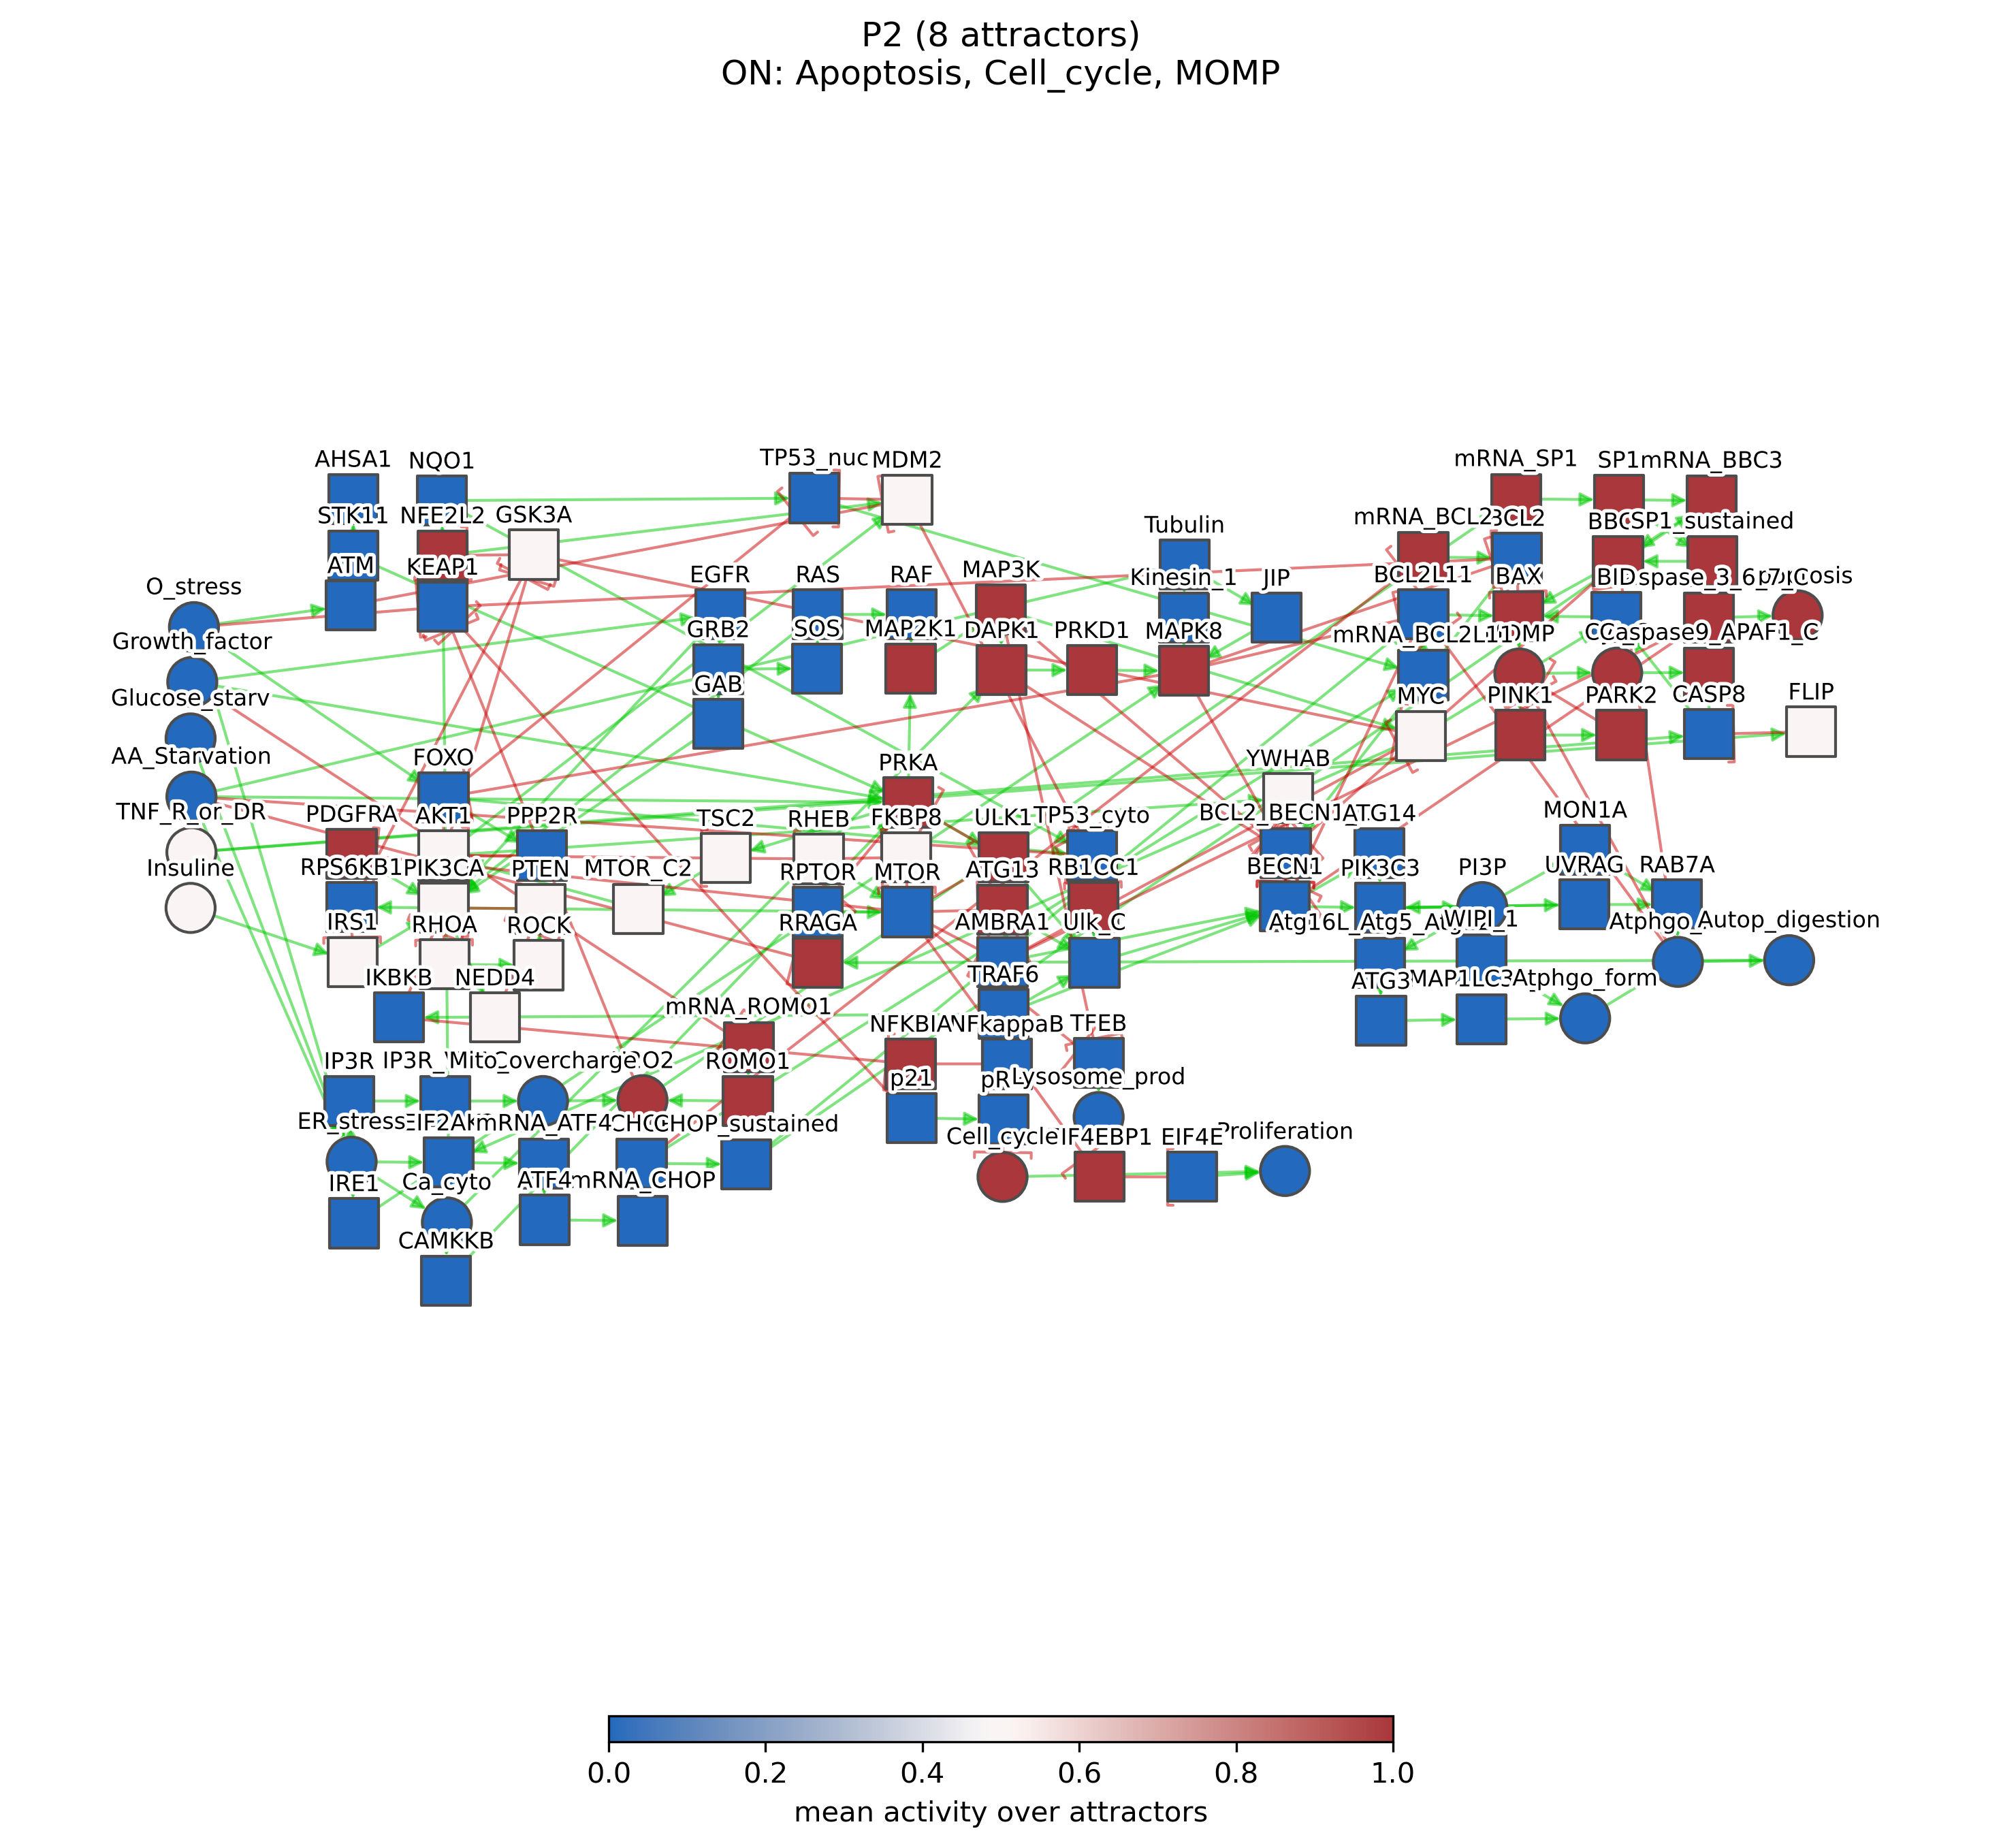

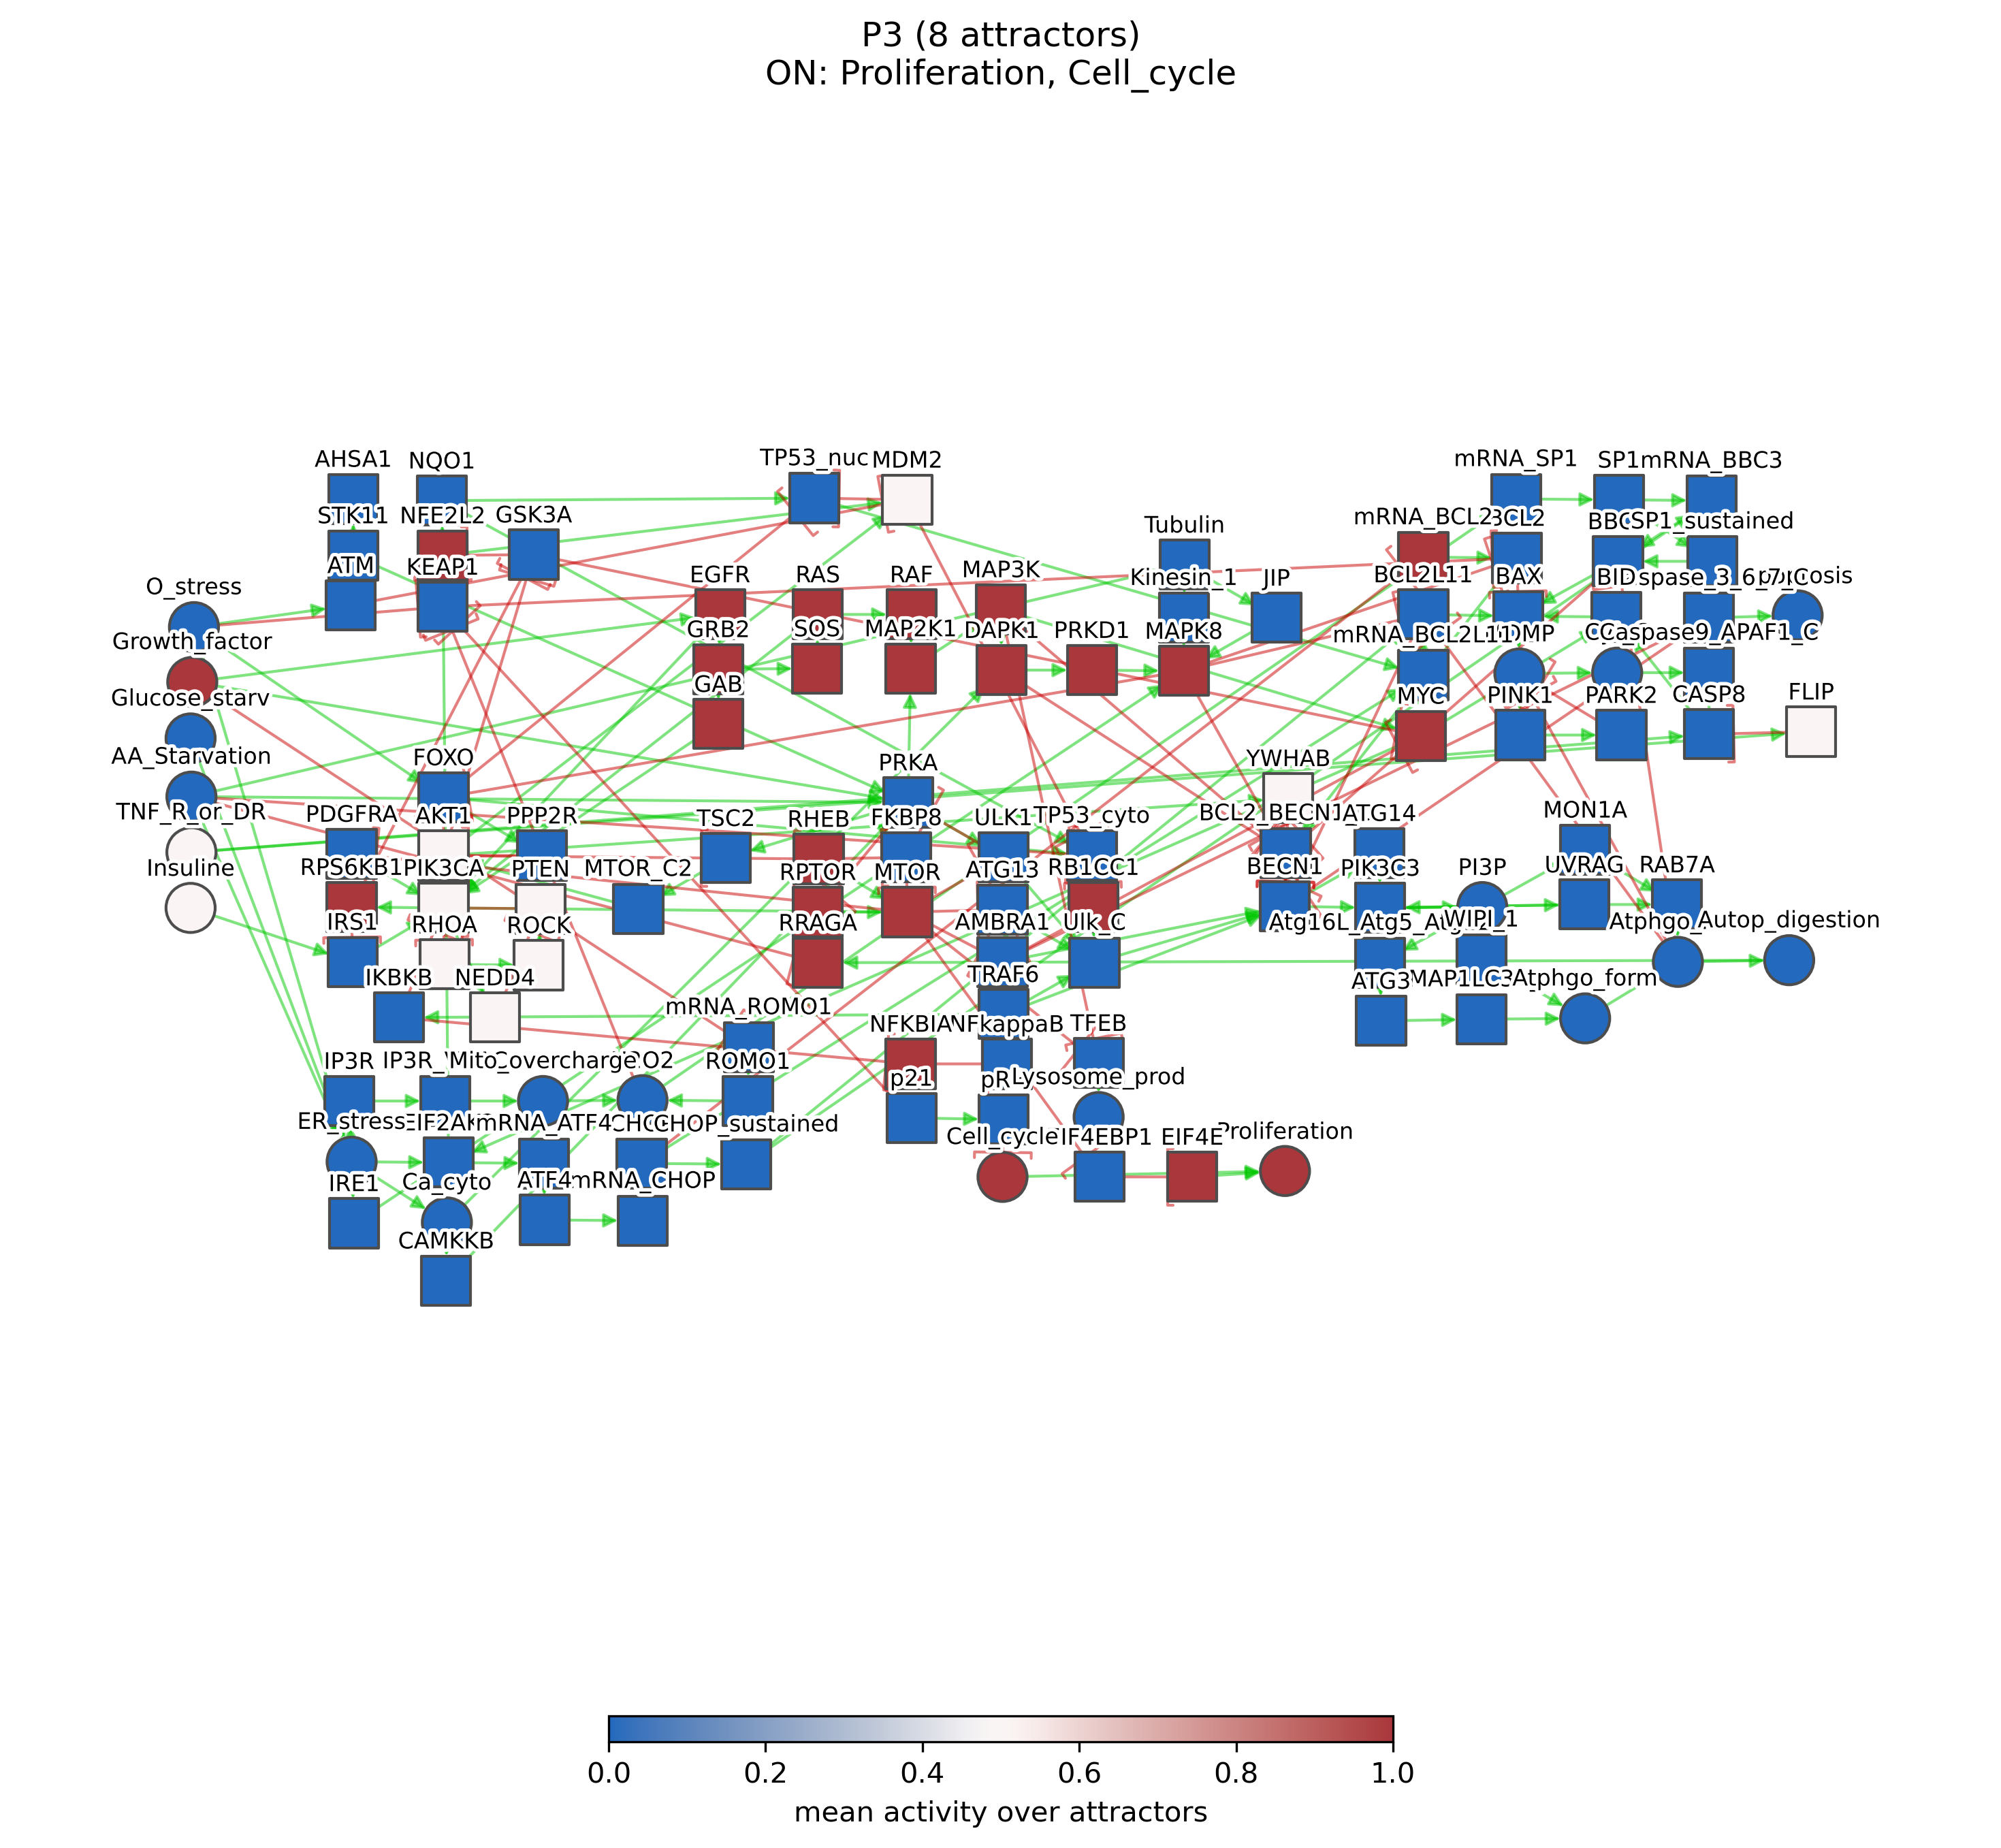

In [11]:
class_size = attractor_states["phenotype"].value_counts()

def describe(p):
    """Title text: outputs ON in class `p`, then those free / oscillating."""
    out = phenotype_activity.loc[p, output_list]
    text = "ON: " + (", ".join(out.index[out == 1]) or "none")
    free = out.index[(out > 0) & (out < 1)]
    return text + ("\nfree / oscillating: " + ", ".join(free) if len(free) else "")

# One network per class; `time=` picks a row of the activity table by its index label
for p in phenotype_order:
    mv.plot_activity(ginsim, phenotype_activity, time=p, cmap="vlag", size_by=False,
                     node_size=300, figsize=(12, 10), label="mean activity over attractors",
                     title=f"{p} ({class_size[p]} attractors)\n{describe(p)}")
    plt.show()